In [31]:
# Import libraries
!pip install gensim


   AVG_DOWNHOLE_PRESSURE  AVG_DOWNHOLE_TEMPERATURE  BORE_OIL_VOL  Cluster
0                0.00000                   0.00000           0.0        2
4              310.37614                  96.87589           0.0        2
5              303.50078                  96.92339           0.0        2
6              303.53481                  96.95885           0.0        2
7              303.78228                  96.96873           0.0        2


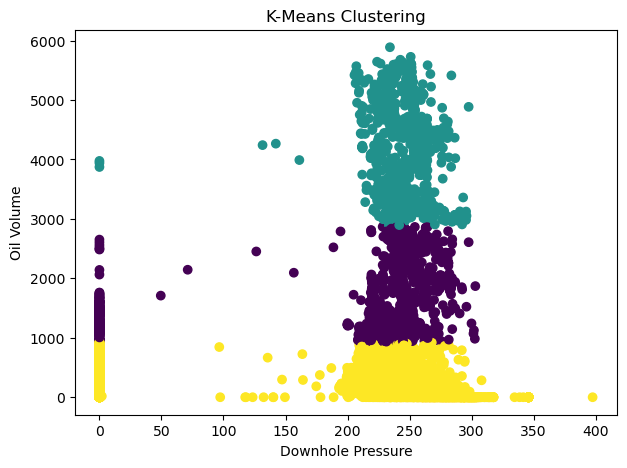

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

# Load dataset
df = pd.read_excel(r"C:\Users\EileneAnnaKuriakose\Desktop\Volve production data.xlsx")

# Select numerical columns
X = df[['AVG_DOWNHOLE_PRESSURE',
        'AVG_DOWNHOLE_TEMPERATURE',
        'BORE_OIL_VOL']]

# Remove missing values
X = X.dropna()

# KMeans
model = KMeans(n_clusters=3, random_state=42)

X['Cluster'] = model.fit_predict(X)

print(X.head())

# Scatter Plot
plt.figure(figsize=(7,5))

plt.scatter(
    X['AVG_DOWNHOLE_PRESSURE'],
    X['BORE_OIL_VOL'],
    c=X['Cluster']
)

plt.xlabel("Downhole Pressure")
plt.ylabel("Oil Volume")
plt.title("K-Means Clustering")

plt.show()

In [37]:
import numpy as np

# Q Table
Q = np.zeros((2,2))

learning_rate = 0.8
gamma = 0.9

# Reward matrix
R = np.array([
    [0,1],
    [0,10]
])

# Training
for i in range(10):
    state = np.random.randint(2)
    action = np.random.randint(2)

    Q[state,action] = R[state,action] + gamma*np.max(Q[action])

print("Q Table:")
print(Q)

Q Table:
[[ 0.9 10. ]
 [ 9.  10. ]]


In [38]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

words = ["playing","played","plays","player"]

for word in words:
    print(word,"->",stemmer.stem(word))

playing -> play
played -> play
plays -> play
player -> player


In [39]:
import nltk
nltk.download('wordnet')

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

words = ["cars","running","better"]

for word in words:
    print(word,"->",lemmatizer.lemmatize(word))

cars -> car
running -> running
better -> better


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\EileneAnnaKuriakose\AppData\Roaming\nltk_data
[nltk_data]     ...
[nltk_data]   Package wordnet is already up-to-date!


In [40]:
from sklearn.feature_extraction.text import CountVectorizer

text = [
    "I love AI",
    "AI loves Python"
]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(text)

print(vectorizer.get_feature_names_out())
print(X.toarray())

['ai' 'love' 'loves' 'python']
[[1 1 0 0]
 [1 0 1 1]]


In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

text = [
    "I love AI",
    "AI loves Python"
]

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(text)

print(vectorizer.get_feature_names_out())
print(X.toarray())

['ai' 'love' 'loves' 'python']
[[0.57973867 0.81480247 0.         0.        ]
 [0.44943642 0.         0.6316672  0.6316672 ]]


In [42]:
from gensim.models import Word2Vec

sentences = [
    ["I","love","AI"],
    ["AI","is","smart"],
    ["I","love","Python"]
]

model = Word2Vec(sentences, vector_size=10, window=2, min_count=1)

print(model.wv["AI"])

[-0.00536227  0.00236431  0.0510335   0.09009273 -0.0930295  -0.07116809
  0.06458873  0.08972988 -0.05015428 -0.03763372]


Accuracy : 1.0


C:\Users\EileneAnnaKuriakose\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


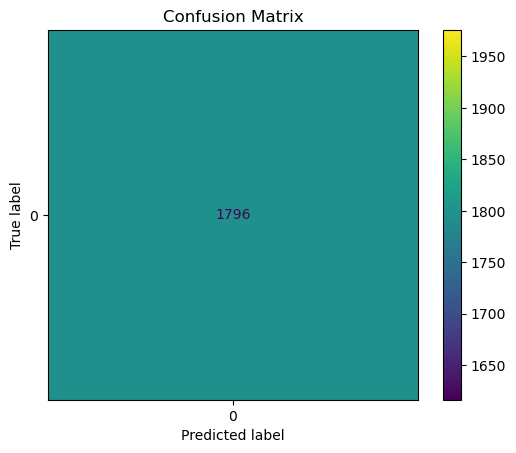

In [45]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_excel(r"C:\Users\EileneAnnaKuriakose\Desktop\Volve production data.xlsx")

# Select required columns
df = df[['AVG_DOWNHOLE_PRESSURE',
         'AVG_DOWNHOLE_TEMPERATURE',
         'AVG_DP_TUBING',
         'AVG_WHP_P',
         'FLOW_KIND']]

# Remove missing values
df = df.dropna()

# Encode labels
encoder = LabelEncoder()

df['FLOW_KIND'] = encoder.fit_transform(df['FLOW_KIND'])

# Features
X = df[['AVG_DOWNHOLE_PRESSURE',
        'AVG_DOWNHOLE_TEMPERATURE',
        'AVG_DP_TUBING',
        'AVG_WHP_P']]

# Target
y = df['FLOW_KIND']

# Split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ANN
model = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=1000,
    random_state=42
)

model.fit(X_train,y_train)

# Prediction
y_pred=model.predict(X_test)

print("Accuracy :",accuracy_score(y_test,y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

plt.title("Confusion Matrix")

plt.show()